In [ ]:
import os
from google.colab import auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload

zip_path = 'Africa.zip'
target_file_id = '1Ng3JwsjJPApshk8lJdGcsNHI52NaEMDX'

# Force un re-téléchargement si le fichier existe déjà (potentiellement corrompu)
if os.path.exists(zip_path):
    print(f"Suppression du fichier existant '{zip_path}' pour forcer un re-téléchargement.")
    os.remove(zip_path)

if not os.path.exists(zip_path):
    try:
        print("1. Authentification Google Cloud (veuillez suivre les instructions à l'écran) :")
        auth.authenticate_user()

        drive_service = build('drive', 'v3')

        print("\n2. Recherche du fichier réel 'Africa.zip' (29.49 Go) dans votre espace...")
        results = drive_service.files().list(
            q="name = 'Africa.zip' and trashed = false",
            fields="files(id, name, size, mimeType)"
        ).execute()

        items = results.get('files', [])
        if not items:
            raise FileNotFoundError("Le fichier 'Africa.zip' n'a pas été trouvé. Assurez-vous d'avoir ajouté le raccourci sur votre Drive.")

        # Filtrer pour obtenir le vrai fichier binaire et non le raccourci (shortcut)
        binary_file = None
        for item in items:
            # On cherche soit l'ID d'origine, soit un fichier avec une taille valide (> 1 Go)
            if item['id'] == target_file_id or (item.get('size') and int(item['size']) > 1000000000):
                binary_file = item
                break

        if binary_file is None:
            # Par défaut, on prend le premier qui a une taille physique définie
            binary_file = next((img for img in items if img.get('size') and int(img['size']) > 0), items[0])

        file_id = binary_file['id']
        file_size = int(binary_file.get('size', 0))

        print(f"Fichier binaire trouvé ! ID: {file_id}, Taille : {file_size / (1024*1024*1024):.2f} Go")
        print("\n3. Début du transfert direct vers Colab (très rapide via le réseau Google)...\n")

        request = drive_service.files().get_media(fileId=file_id)
        with open(zip_path, 'wb') as f:
            downloader = MediaIoBaseDownload(f, request, chunksize=1024*1024*100) # Morceaux de 100 Mo
            done = False
            while done is False:
                status, done = downloader.next_chunk()
                if status:
                    # Calcul manuel robuste pour éviter les soucis de type avec status.progress
                    downloaded_bytes = status.resumable_progress
                    percent = int((downloaded_bytes / file_size) * 100) if file_size > 0 else 0
                    downloaded_gb = downloaded_bytes / (1024*1024*1024)
                    total_gb = file_size / (1024*1024*1024)
                    print(f"Progression : {percent}% ({downloaded_gb:.2f} Go / {total_gb:.2f} Go)", end='\r')

        print("\nTéléchargement terminé avec succès !")
    except Exception as e:
        print(f"\nErreur : {e}")
        print("Si l'erreur persiste, vous pouvez également essayer de copier l'ID cible directement : '1Ng3JwsjJPApshk8lJdGcsNHI52NaEMDX'")
else:
    print(f"Le fichier '{zip_path}' est déjà présent ({os.path.getsize(zip_path) / (1024*1024*1024):.2f} Go).")

Suppression du fichier existant 'Africa.zip' pour forcer un re-téléchargement.
1. Authentification Google Cloud (veuillez suivre les instructions à l'écran) :



2. Recherche du fichier réel 'Africa.zip' (29.49 Go) dans votre espace...
Fichier binaire trouvé ! ID: 1Ng3JwsjJPApshk8lJdGcsNHI52NaEMDX, Taille : 29.49 Go

3. Début du transfert direct vers Colab (très rapide via le réseau Google)...

Progression : 100% (29.49 Go / 29.49 Go)
Téléchargement terminé avec succès !


In [ ]:
import os
from google.colab import auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload

zip_path_europe='Europe.zip'
target_file_id_europe='1vANGtfuEdn0ZnILA6BYXW1_7jt8CU0gA'

zip_path = zip_path_europe
target_file_id = target_file_id_europe

# Nettoyage si un résidu incomplet existe
if os.path.exists(zip_path) and os.path.getsize(zip_path) < 1000000000: # Moins de 1 Go
    print("Nettoyage du fichier incomplet...")
    os.remove(zip_path)

if not os.path.exists(zip_path):
    try:
        print("1. Authentification Google Cloud (veuillez suivre les instructions à l'écran) :")
        auth.authenticate_user()

        drive_service = build('drive', 'v3')

        print("\n2. Recherche du fichier réel 'Europe.zip' dans votre espace...")
        results = drive_service.files().list(
            q="name = 'Europe.zip' and trashed = false",
            fields="files(id, name, size, mimeType)"
        ).execute()

        items = results.get('files', [])
        if not items:
            raise FileNotFoundError("Le fichier 'Europe.zip' n'a pas été trouvé. Assurez-vous d'avoir ajouté le raccourci sur votre Drive.")

        # Filtrer pour obtenir le vrai fichier binaire et non le raccourci (shortcut)
        binary_file = None
        for item in items:
            # On cherche soit l'ID d'origine, soit un fichier avec une taille valide (> 1 Go)
            if item['id'] == target_file_id or (item.get('size') and int(item['size']) > 1000000000):
                binary_file = item
                break

        if binary_file is None:
            # Par défaut, on prend le premier qui a une taille physique définie
            binary_file = next((img for img in items if img.get('size') and int(img['size']) > 0), items[0])

        file_id = binary_file['id']
        file_size = int(binary_file.get('size', 0))

        print(f"Fichier binaire trouvé ! ID: {file_id}, Taille : {file_size / (1024*1024*1024):.2f} Go")
        print("\n3. Début du transfert direct vers Colab (très rapide via le réseau Google)...\n")

        request = drive_service.files().get_media(fileId=file_id)
        with open(zip_path, 'wb') as f:
            downloader = MediaIoBaseDownload(f, request, chunksize=1024*1024*100) # Morceaux de 100 Mo
            done = False
            while done is False:
                status, done = downloader.next_chunk()
                if status:
                    # Calcul manuel robuste pour éviter les soucis de type avec status.progress
                    downloaded_bytes = status.resumable_progress
                    percent = int((downloaded_bytes / file_size) * 100) if file_size > 0 else 0
                    downloaded_gb = downloaded_bytes / (1024*1024*1024)
                    total_gb = file_size / (1024*1024*1024)
                    print(f"Progression : {percent}% ({downloaded_gb:.2f} Go / {total_gb:.2f} Go)", end='\r')

        print("\nTéléchargement terminé avec succès !")
    except Exception as e:
        print(f"\nErreur : {e}")
        print(f"Si l'erreur persiste, vous pouvez également essayer de copier l'ID cible directement : '{target_file_id_europe}'")
else:
    print(f"Le fichier '{zip_path}' est déjà présent ({os.path.getsize(zip_path) / (1024*1024*1024):.2f} Go).")

Nettoyage du fichier incomplet...
1. Authentification Google Cloud (veuillez suivre les instructions à l'écran) :



2. Recherche du fichier réel 'Europe.zip' dans votre espace...
Fichier binaire trouvé ! ID: 1vANGtfuEdn0ZnILA6BYXW1_7jt8CU0gA, Taille : 15.31 Go

3. Début du transfert direct vers Colab (très rapide via le réseau Google)...

Progression : 100% (15.31 Go / 15.31 Go)
Téléchargement terminé avec succès !


In [ ]:
import zipfile

# Chemin du fichier zip
zip_path = 'Africa.zip'

print("Analyse de la structure interne du fichier ZIP en cours...")
with zipfile.ZipFile(zip_path, 'r') as archive:
    all_files = archive.namelist()

print(f"Nombre total de fichiers dans l'archive : {len(all_files)}")

# Recherche des motifs ou dossiers contenant 'north' ou 'nord' (insensible à la casse)
north_africa_files = [
    f for f in all_files
    if 'north' in f.lower() or 'nord' in f.lower()
]

print(f"Nombre de fichiers identifiés pour l'Afrique du Nord : {len(north_africa_files)}")
if north_africa_files:
    print("Exemples de chemins trouvés :")
    for path in north_africa_files[:15]:
        print(f" - {path}")
else:
    print("Aucun dossier ou fichier contenant explicitement 'north' ou 'nord' n'a été détecté.")
    print("Affichage des 20 premiers fichiers de l'archive pour comprendre sa structure :")
    for path in all_files[:20]:
        print(f" - {path}")

Analyse de la structure interne du fichier ZIP en cours...
Nombre total de fichiers dans l'archive : 1475
Nombre de fichiers identifiés pour l'Afrique du Nord : 0
Aucun dossier ou fichier contenant explicitement 'north' ou 'nord' n'a été détecté.
Affichage des 20 premiers fichiers de l'archive pour comprendre sa structure :
 - z166052.zip
 - z166052_masks.zip
 - z166052_masks_derivates.zip
 - z166053.zip
 - z166053_masks.zip
 - z166053_masks_derivates.zip
 - z166054.zip
 - z166054_masks.zip
 - z166055.zip
 - z166055_masks.zip
 - z166055_masks_derivates.zip
 - z166056.zip
 - z166056_masks.zip
 - z166056_masks_derivates.zip
 - z166057.zip
 - z166057_masks.zip
 - z166057_masks_derivates.zip
 - z166058.zip
 - z166058_masks.zip
 - z166058_masks_derivates.zip


In [ ]:
KEEP_NO_FIRE_PATCHES = True
import zipfile, io, os
import rasterio
from rasterio.warp import transform_bounds
import numpy as np

MIN_LON, MAX_LON = -17.0, 37.0
MIN_LAT, MAX_LAT = 15.0, 38.0

def is_in_north_africa(dataset_reader):
    bounds = dataset_reader.bounds
    min_lon_t, min_lat_t, max_lon_t, max_lat_t = transform_bounds(
        dataset_reader.crs, 'EPSG:4326', bounds.left, bounds.bottom, bounds.right, bounds.top)
    return not (max_lon_t < MIN_LON or min_lon_t > MAX_LON or max_lat_t < MIN_LAT or min_lat_t > MAX_LAT)

matched_pairs = []
print("Recherche et filtrage géographique des tuiles...")
with zipfile.ZipFile('Africa.zip', 'r') as main_archive:
    all_files = main_archive.namelist()
    image_zips = [f for f in all_files if f.endswith('.zip') and '_masks' not in f]
    for img_zip in image_zips:
        prefix = img_zip.replace('.zip', '')
        mask_zip_name = f"{prefix}_masks.zip"
        if mask_zip_name in all_files or KEEP_NO_FIRE_PATCHES:
            with main_archive.open(img_zip) as inner_file:
                with zipfile.ZipFile(io.BytesIO(inner_file.read())) as sub_archive:
                    sub_files = sub_archive.namelist()
                    if not sub_files:
                        continue
                    with sub_archive.open(sub_files[0]) as t_file:
                        with rasterio.MemoryFile(t_file.read()) as memfile, memfile.open() as src:
                            if not is_in_north_africa(src):
                                continue
            if mask_zip_name in all_files:
                with main_archive.open(mask_zip_name) as inner_mask_file:
                    with zipfile.ZipFile(io.BytesIO(inner_mask_file.read())) as sub_mask_archive:
                        mask_files = sub_mask_archive.namelist()
            else:
                mask_files = []
            for img_name in sub_files:
                patch_id = img_name.replace('.tif', '').split('_')[-1]
                schroeder_mask_name = f"_Schroeder_{patch_id}.tif"
                matching_mask = [m for m in mask_files if schroeder_mask_name in m]
                if matching_mask:
                    matched_pairs.append({'img_zip': img_zip, 'img_name': img_name,
                                          'mask_zip': mask_zip_name, 'mask_name': matching_mask[0]})
                elif KEEP_NO_FIRE_PATCHES:
                    matched_pairs.append({'img_zip': img_zip, 'img_name': img_name,
                                          'mask_zip': mask_zip_name, 'mask_name': None})

print(f"\nFiltrage terminé ! Paires trouvées en Afrique du Nord : {len(matched_pairs)}")
print(f"  dont patches sans masque Schroeder (aucun feu) : {sum(p['mask_name'] is None for p in matched_pairs)}")

Recherche et filtrage géographique des tuiles...

Filtrage terminé ! Paires trouvées en Afrique du Nord : 1350
  dont patches sans masque Schroeder (aucun feu) : 589


In [ ]:
KEEP_NO_FIRE_PATCHES = True
import zipfile, io, os
import rasterio
from rasterio.warp import transform_bounds
import numpy as np

SOUTH_EUROPE_MIN_LON, SOUTH_EUROPE_MAX_LON = -10.0, 30.0
SOUTH_EUROPE_MIN_LAT, SOUTH_EUROPE_MAX_LAT = 35.0, 48.0

def is_in_south_europe(dataset_reader):
    bounds = dataset_reader.bounds
    min_lon_t, min_lat_t, max_lon_t, max_lat_t = transform_bounds(
        dataset_reader.crs, 'EPSG:4326', bounds.left, bounds.bottom, bounds.right, bounds.top)
    return not (max_lon_t < SOUTH_EUROPE_MIN_LON or min_lon_t > SOUTH_EUROPE_MAX_LON or
                max_lat_t < SOUTH_EUROPE_MIN_LAT or min_lat_t > SOUTH_EUROPE_MAX_LAT)

matched_pairs_europe = []
print("Recherche et filtrage géographique des tuiles pour l'Europe du Sud...")
with zipfile.ZipFile('Europe.zip', 'r') as main_archive:
    all_files_europe = main_archive.namelist()
    image_zips_europe = [f for f in all_files_europe if f.endswith('.zip') and '_masks' not in f]
    for img_zip in image_zips_europe:
        prefix = img_zip.replace('.zip', '')
        mask_zip_name = f"{prefix}_masks.zip"
        if mask_zip_name in all_files_europe or KEEP_NO_FIRE_PATCHES:
            with main_archive.open(img_zip) as inner_file:
                with zipfile.ZipFile(io.BytesIO(inner_file.read())) as sub_archive:
                    sub_files = sub_archive.namelist()
                    if not sub_files:
                        continue
                    with sub_archive.open(sub_files[0]) as t_file:
                        with rasterio.MemoryFile(t_file.read()) as memfile, memfile.open() as src:
                            if not is_in_south_europe(src):
                                continue
            if mask_zip_name in all_files_europe:
                with main_archive.open(mask_zip_name) as inner_mask_file:
                    with zipfile.ZipFile(io.BytesIO(inner_mask_file.read())) as sub_mask_archive:
                        mask_files = sub_mask_archive.namelist()
            else:
                mask_files = []
            for img_name in sub_files:
                patch_id = img_name.replace('.tif', '').split('_')[-1]
                schroeder_mask_name = f"_Schroeder_{patch_id}.tif"
                matching_mask = [m for m in mask_files if schroeder_mask_name in m]
                if matching_mask:
                    matched_pairs_europe.append({'img_zip': img_zip, 'img_name': img_name,
                                                 'mask_zip': mask_zip_name, 'mask_name': matching_mask[0]})
                elif KEEP_NO_FIRE_PATCHES:
                    matched_pairs_europe.append({'img_zip': img_zip, 'img_name': img_name,
                                                 'mask_zip': mask_zip_name, 'mask_name': None})

print(f"\nFiltrage terminé ! Paires trouvées en Europe du Sud : {len(matched_pairs_europe)}")
print(f"  dont patches sans masque Schroeder (aucun feu) : {sum(p['mask_name'] is None for p in matched_pairs_europe)}")

Recherche et filtrage géographique des tuiles pour l'Europe du Sud...

Filtrage terminé ! Paires trouvées en Europe du Sud : 5214
  dont patches sans masque Schroeder (aucun feu) : 3507


In [ ]:
import re
from collections import defaultdict, Counter
from tqdm.auto import tqdm

ALGO_RE = re.compile(r'_(Schroeder|Murphy|Kumar-Roy)_(p\d+)\.tif$')

def algo_coverage(main_zip_path, region_name):
    coverage = Counter()
    with zipfile.ZipFile(main_zip_path, 'r') as main:
        mask_zips = [f for f in main.namelist() if f.endswith('_masks.zip')]
        for mz in tqdm(mask_zips, desc=f"Scanning masks - {region_name}"):
            with main.open(mz) as f:
                with zipfile.ZipFile(io.BytesIO(f.read())) as zm:
                    per_patch = defaultdict(set)
                    for name in zm.namelist():
                        m = ALGO_RE.search(name)
                        if m:
                            algo, pid = m.groups()
                            per_patch[pid].add(algo)
            for algos in per_patch.values():
                coverage[frozenset(algos)] += 1
    return coverage

coverage_summary = {}
for region, path in [("North Africa", "Africa.zip"), ("South Europe", "Europe.zip")]:
    cov = algo_coverage(path, region)
    total = sum(cov.values())
    print(f"\n--- {region} ({total} patches with >=1 algorithm mask) ---")
    for combo, n in sorted(cov.items(), key=lambda kv: -kv[1]):
        print(f"  {sorted(combo)}: {n} ({100*n/total:.1f}%)")
    n_no_schroeder = sum(n for combo, n in cov.items() if "Schroeder" not in combo)
    pct = 100 * n_no_schroeder / total if total else 0.0
    print(f"  => Schroeder-negative (Murphy/Kumar-Roy only): {n_no_schroeder} ({pct:.1f}%)")
    coverage_summary[region] = pct

HAS_REAL_NEGATIVES = any(v > 0 for v in coverage_summary.values())
if not HAS_REAL_NEGATIVES:
    print("\nWARNING: 0% Schroeder-negative patches in both regions. This archive appears to contain "
          "only Schroeder-flagged patches. KEEP_NO_FIRE_PATCHES cannot recover negatives that were never "
          "included in the archive -- see the note in cell 9 about what this means for your metrics.")

Scanning masks - North Africa:   0%|          | 0/513 [00:00<?, ?it/s]


--- North Africa (27727 patches with >=1 algorithm mask) ---
  ['Kumar-Roy', 'Murphy', 'Schroeder']: 17685 (63.8%)
  ['Kumar-Roy', 'Murphy']: 4658 (16.8%)
  ['Kumar-Roy']: 4448 (16.0%)
  ['Schroeder']: 359 (1.3%)
  ['Murphy']: 330 (1.2%)
  ['Kumar-Roy', 'Schroeder']: 233 (0.8%)
  ['Murphy', 'Schroeder']: 14 (0.1%)
  => Schroeder-negative (Murphy/Kumar-Roy only): 9436 (34.0%)


Scanning masks - South Europe:   0%|          | 0/389 [00:00<?, ?it/s]


--- South Europe (14110 patches with >=1 algorithm mask) ---
  ['Kumar-Roy']: 7565 (53.6%)
  ['Kumar-Roy', 'Murphy', 'Schroeder']: 3046 (21.6%)
  ['Kumar-Roy', 'Murphy']: 1711 (12.1%)
  ['Kumar-Roy', 'Schroeder']: 1544 (10.9%)
  ['Murphy']: 168 (1.2%)
  ['Schroeder']: 68 (0.5%)
  ['Murphy', 'Schroeder']: 8 (0.1%)
  => Schroeder-negative (Murphy/Kumar-Roy only): 9444 (66.9%)


In [ ]:
import os, io, sys, json, random, zipfile, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from tqdm.auto import tqdm
from IPython.display import display

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED)

BAND_NAMES = ["c7", "c6", "c2"]
BAND_INDICES = [6, 5, 1]
PATCH_SIZE = 256                     # size of the archive's source patches (unchanged); val/test train at this size
SCALE = 65535.0

TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.10, 0.20   # matches your actual run, not the paper's 40/10/50
SPLIT_MODE = "paper"                # "paper" = random patches | "scene" = split by Landsat scene (no leakage)
MAX_PATCHES = None

BASE_FILTERS = 16
DROPOUT = 0.1
BN_MOMENTUM = 0.9
LEARNING_RATE = 1e-3
BATCH_SIZE = 16
EPOCHS = 50
PATIENCE = 8
THRESHOLD = 0.25

FIRE_MIN_PIXELS = 5          # a patch needs at least this many fire pixels to serve as a crop source
CROP_SIZE = 128              # training input size -- must be divisible by 16 (4 pooling stages)
FOREGROUND_FRACTION = 0.5    # share of every TRAINING batch guaranteed to contain a real fire pixel
CROP_JITTER = 16             # random offset (px) so the fire pixel isn't always dead-centre in its crop
TVERSKY_ALPHA = 0.3
TVERSKY_BETA = 0.7
TVERSKY_GAMMA = 0.75

PAPER_TARGET = {"P": 90.8, "R": 86.1, "IoU": 79.2, "F": 88.4}
TARGET_PARAMS = 2_161_649

RUN_DIR = Path("/content/output_unetlight3c")
RUN_DIR.mkdir(parents=True, exist_ok=True)
print("RUN_DIR:", RUN_DIR)
print(f"v3 balanced-crop training: crop {CROP_SIZE}x{CROP_SIZE}, foreground fraction {FOREGROUND_FRACTION}, "
      f"jitter +/-{CROP_JITTER}px, fire-source threshold {FIRE_MIN_PIXELS}px, "
      f"focal Tversky (alpha={TVERSKY_ALPHA}, beta={TVERSKY_BETA}, gamma={TVERSKY_GAMMA}), lr={LEARNING_RATE}")

RUN_DIR: /content/output_unetlight3c
v3 balanced-crop training: crop 128x128, foreground fraction 0.5, jitter +/-16px, fire-source threshold 5px, focal Tversky (alpha=0.3, beta=0.7, gamma=0.75), lr=0.001


In [ ]:
def build_cache(pairs, main_zip_path, region_name, band_indices=BAND_INDICES,
                patch_size=PATCH_SIZE, max_patches=MAX_PATCHES):
    pairs = list(pairs)
    if max_patches is not None and len(pairs) > max_patches:
        rng = np.random.RandomState(SEED)
        pairs = [pairs[i] for i in sorted(rng.choice(len(pairs), max_patches, replace=False))]
    groups = defaultdict(list)
    for p in pairs:
        groups[(p["img_zip"], p["mask_zip"])].append(p)

    images, masks, scenes, stems, has_mask = [], [], [], [], []
    skipped, info, mask_values = 0, None, set()
    with zipfile.ZipFile(main_zip_path, "r") as main:
        names = set(main.namelist())
        for (img_zip, mask_zip), items in tqdm(groups.items(), desc=f"Caching {region_name}"):
            zm = zipfile.ZipFile(io.BytesIO(main.read(mask_zip))) if mask_zip in names else None
            with zipfile.ZipFile(io.BytesIO(main.read(img_zip))) as zi:
                for p in items:
                    with rasterio.MemoryFile(zi.read(p["img_name"])) as mf, mf.open() as src:
                        if src.count <= max(band_indices):
                            raise ValueError(f"{p['img_name']} has {src.count} bands; indices {band_indices} unavailable")
                        if info is None:
                            info = {"n_bands": src.count, "dtype": src.dtypes[0]}
                        bands = src.read([b + 1 for b in band_indices])
                    if p["mask_name"] is None or zm is None:
                        mask = np.zeros(bands.shape[1:], dtype=np.uint8)
                    else:
                        with rasterio.MemoryFile(zm.read(p["mask_name"])) as mf, mf.open() as src:
                            mask = src.read(1)
                        mask_values.update(np.unique(mask).tolist())
                    if bands.shape[1:] != (patch_size, patch_size) or mask.shape != (patch_size, patch_size):
                        skipped += 1
                        continue
                    images.append(np.moveaxis(bands, 0, -1))
                    masks.append((mask > 0).astype(np.uint8))
                    scenes.append(f"{region_name}/{img_zip}")
                    stems.append(p["img_name"].replace(".tif", ""))
                    has_mask.append(p["mask_name"] is not None)
            if zm is not None:
                zm.close()

    print(f"{region_name}: cached {len(images)} patches | skipped (unexpected shape): {skipped} | "
          f"tile info: {info} | mask values seen: {sorted(mask_values)}")
    return {"images": np.stack(images), "masks": np.stack(masks), "scenes": np.array(scenes),
            "stems": np.array(stems), "has_mask": np.array(has_mask, dtype=bool)}


cache_africa = build_cache(matched_pairs, "Africa.zip", "North Africa")
cache_europe = build_cache(matched_pairs_europe, "Europe.zip", "South Europe")

cache = {k: np.concatenate([cache_africa[k], cache_europe[k]]) for k in cache_africa}
cache["region"] = np.concatenate([np.zeros(len(cache_africa["images"]), np.int8),
                                  np.ones(len(cache_europe["images"]), np.int8)])
del cache_africa, cache_europe
print(f"\nPooled: {len(cache['images'])} patches, images {cache['images'].shape} {cache['images'].dtype}, "
      f"{cache['images'].nbytes / 1e9:.2f} GB")

Caching North Africa:   0%|          | 0/110 [00:00<?, ?it/s]

North Africa: cached 1350 patches | skipped (unexpected shape): 0 | tile info: {'n_bands': 10, 'dtype': 'uint16'} | mask values seen: [0, 1]


Caching South Europe:   0%|          | 0/109 [00:00<?, ?it/s]

South Europe: cached 5214 patches | skipped (unexpected shape): 0 | tile info: {'n_bands': 10, 'dtype': 'uint16'} | mask values seen: [0, 1]

Pooled: 6564 patches, images (6564, 256, 256, 3) uint16, 2.58 GB


In [ ]:
def load_other_masks_for_patch(main_zip_path, img_zip_name, patch_id):
    """Loads Kumar-Roy and Murphy masks for a specific patch_id."""
    kumar_mask = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=np.uint8)
    murphy_mask = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=np.uint8)

    # Regular expression to find specific masks for the given patch_id
    kumar_re = re.compile(rf'_Kumar-Roy_{patch_id}\.tif$')
    murphy_re = re.compile(rf'_Murphy_{patch_id}\.tif$')

    try:
        with zipfile.ZipFile(main_zip_path, 'r') as main_archive:
            # Open the masks zip file for the specific image zip
            mask_zip_name = img_zip_name.replace('.zip', '_masks.zip')
            if mask_zip_name not in main_archive.namelist():
                # If _masks.zip doesn't exist, return empty masks
                return kumar_mask, murphy_mask

            with main_archive.open(mask_zip_name) as inner_mask_file:
                with zipfile.ZipFile(io.BytesIO(inner_mask_file.read())) as sub_mask_archive:
                    for mask_filename in sub_mask_archive.namelist():
                        if kumar_re.search(mask_filename):
                            with rasterio.MemoryFile(sub_mask_archive.read(mask_filename)) as mf, mf.open() as src:
                                kumar_mask = src.read(1)
                                if kumar_mask.shape != (PATCH_SIZE, PATCH_SIZE):
                                    kumar_mask = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=np.uint8)
                        elif murphy_re.search(mask_filename):
                            with rasterio.MemoryFile(sub_mask_archive.read(mask_filename)) as mf, mf.open() as src:
                                murphy_mask = src.read(1)
                                if murphy_mask.shape != (PATCH_SIZE, PATCH_SIZE):
                                    murphy_mask = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=np.uint8)
    except Exception as e:
        print(f"Error loading other masks for {patch_id} in {img_zip_name}: {e}")

    return kumar_mask, murphy_mask

In [ ]:
imgs, msk = cache["images"], cache["masks"]
n = len(imgs)
has_fire = msk.reshape(n, -1).max(axis=1) > 0
no_mask = ~cache["has_mask"]

print(f"patches: {n} | scenes: {len(set(cache['scenes']))} | North Africa: {(cache['region'] == 0).sum()} | South Europe: {(cache['region'] == 1).sum()}")
print(f"patches WITHOUT a stored Schroeder mask (treated as no fire): {no_mask.sum()} ({no_mask.mean() * 100:.1f} %)")
print(f"patches with >= 1 fire pixel: {has_fire.sum()} ({has_fire.mean() * 100:.2f} %)")
print(f"fire pixels: {msk.mean() * 100:.4f} % of all pixels | accuracy of 'always no fire': {(1 - msk.mean()) * 100:.4f} %")
for k, name in enumerate(BAND_NAMES):
    band = imgs[..., k]
    print(f"raw {name}: min={band.min()}  max={band.max()}  mean={band.mean():.1f}  -> max / SCALE = {band.max() / SCALE:.3f}")

if 'HAS_REAL_NEGATIVES' in globals() and HAS_REAL_NEGATIVES and no_mask.sum() == 0:
    print("\nINCONSISTENCY: cell 5 found real Schroeder-negative patches in the archive, but none made it "
          "into the cache. Check that matched_pairs / matched_pairs_europe were rebuilt after cell 5, "
          "and that build_cache is reading from the same matched_pairs objects.")
if has_fire.mean() > 0.99:
    print("\nNOTE: essentially every cached patch has fire. If cell 5 showed 0% Schroeder-negative "
          "patches, this is expected given the archive's contents (see cell 5's warning) -- the test-set "
          "precision/recall in cell 13 will not reflect real-world (mostly fire-free) deployment.")

patches: 6564 | scenes: 219 | North Africa: 1350 | South Europe: 5214
patches WITHOUT a stored Schroeder mask (treated as no fire): 4096 (62.4 %)
patches with >= 1 fire pixel: 2468 (37.60 %)
fire pixels: 0.0072 % of all pixels | accuracy of 'always no fire': 99.9928 %
raw c7: min=0  max=65535  mean=11897.3  -> max / SCALE = 1.000
raw c6: min=0  max=65535  mean=15566.1  -> max / SCALE = 1.000
raw c2: min=0  max=65535  mean=10413.8  -> max / SCALE = 1.000


In [ ]:
def split_indices(cache, mode=SPLIT_MODE, ratios=(TRAIN_RATIO, VAL_RATIO, TEST_RATIO), seed=SEED):
    n = len(cache["images"])
    rng = np.random.RandomState(seed)
    if mode == "paper":
        perm = rng.permutation(n)
        n_tr, n_va = int(round(ratios[0] * n)), int(round(ratios[1] * n))
        parts = {"train": perm[:n_tr], "val": perm[n_tr:n_tr + n_va], "test": perm[n_tr + n_va:]}
    elif mode == "scene":
        scenes = np.array(sorted(set(cache["scenes"].tolist())))
        assert len(scenes) >= 3, "Need at least 3 scenes for a scene-level split."
        rng.shuffle(scenes)
        n_tr = min(max(1, int(round(ratios[0] * len(scenes)))), len(scenes) - 2)
        n_va = max(1, int(round(ratios[1] * len(scenes))))
        groups = {"train": scenes[:n_tr], "val": scenes[n_tr:n_tr + n_va], "test": scenes[n_tr + n_va:]}
        parts = {k: np.where(np.isin(cache["scenes"], v))[0] for k, v in groups.items()}
    else:
        raise ValueError(mode)
    assert all(len(v) > 0 for v in parts.values()), "One split is empty."
    return {k: np.sort(v) for k, v in parts.items()}


split = split_indices(cache)
rows = []
for k, idx in split.items():
    m = cache["masks"][idx]
    rows.append({"split": k, "patches": len(idx), "share %": round(100 * len(idx) / len(cache["images"]), 1),
                 "North Africa": int((cache["region"][idx] == 0).sum()), "South Europe": int((cache["region"][idx] == 1).sum()),
                 "patches with fire %": round(100 * (m.reshape(len(idx), -1).max(axis=1) > 0).mean(), 1),
                 "fire pixels %": round(100 * m.mean(), 4)})
print(f"SPLIT_MODE = {SPLIT_MODE!r}")
display(pd.DataFrame(rows).set_index("split"))
if (cache["masks"][split["test"]].reshape(len(split["test"]), -1).max(axis=1) > 0).mean() > 0.99:
    print("\nNOTE: the test split is essentially all fire-positive. The P/R/IoU/F reported in cell 13 "
          "describe how well the model finds fire pixels WITHIN already-flagged patches, not how it would "
          "behave on typical (mostly fire-free) satellite imagery.")

SPLIT_MODE = 'paper'


,patches,share %,North Africa,South Europe,patches with fire %,fire pixels %
split,,,,,,
train,4595,70.0,950,3645,37.5,0.0078
val,656,10.0,153,503,39.3,0.0065
test,1313,20.0,247,1066,37.0,0.0055


In [ ]:
import tensorflow as tf

try:
    gpus = tf.config.list_physical_devices("GPU")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPUs:", gpus if gpus else "none (CPU)")
except Exception as e:
    print("GPU configuration skipped:", e)
tf.keras.utils.set_random_seed(SEED)


class TileSequence(tf.keras.utils.Sequence):
    """Full, uncropped patches, no augmentation unless explicitly flagged. Used for val/test and every
    ad-hoc evaluation subset in cell 13 -- unchanged from v2, so evaluation stays comparable to the paper."""
    def __init__(self, cache, indices, augment=None, batch_size=BATCH_SIZE, shuffle=False, **kwargs):
        super().__init__(**kwargs)
        self.images, self.masks = cache["images"], cache["masks"]
        self.indices = np.asarray(indices)
        self.augment = np.zeros(len(self.indices), dtype=bool) if augment is None else np.asarray(augment)
        assert len(self.augment) == len(self.indices)
        self.order = np.arange(len(self.indices))
        self.batch_size, self.shuffle = batch_size, shuffle
        self.rng = np.random.RandomState(SEED)
        if shuffle:
            self.rng.shuffle(self.order)

    def __len__(self):
        return int(np.ceil(len(self.order) / self.batch_size))

    def __getitem__(self, i):
        pos = self.order[i * self.batch_size:(i + 1) * self.batch_size]
        idx, aug = self.indices[pos], self.augment[pos]
        x = self.images[idx].astype(np.float32) / SCALE
        y = self.masks[idx].astype(np.float32)[..., None]
        for b in np.where(aug)[0]:
            k = self.rng.randint(4)
            if self.rng.rand() < 0.5:
                x[b], y[b] = x[b, :, ::-1], y[b, :, ::-1]
            x[b], y[b] = np.rot90(x[b], k), np.rot90(y[b], k)
        return x, y

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.order)


class BalancedCropSequence(tf.keras.utils.Sequence):
    """Every batch is constructed directly, not sliced from a pre-shuffled array. FOREGROUND_FRACTION of
    it is a CROP_SIZE window centred (with jitter) on a real fire pixel, drawn from fg_indices; the rest
    is a random-location CROP_SIZE window drawn from bg_indices. Composition is identical for every batch
    by construction -- see cell 10.1 for a direct check that this holds."""
    def __init__(self, cache, fg_indices, bg_indices, crop_size=CROP_SIZE, fg_fraction=FOREGROUND_FRACTION,
                 jitter=CROP_JITTER, batch_size=BATCH_SIZE, steps_per_epoch=None, seed=SEED, **kwargs):
        super().__init__(**kwargs)
        self.images, self.masks = cache["images"], cache["masks"]
        self.fg_indices = np.asarray(fg_indices)
        self.bg_indices = np.asarray(bg_indices)
        assert len(self.fg_indices) > 0, "No training patch reached FIRE_MIN_PIXELS -- can't build foreground crops."
        self.crop_size, self.patch_size, self.jitter = crop_size, self.images.shape[1], jitter
        self.n_fg = int(round(batch_size * fg_fraction))
        self.n_bg = batch_size - self.n_fg
        self.steps_per_epoch = steps_per_epoch or max(1, len(bg_indices) // batch_size)
        self.rng = np.random.RandomState(seed)

    def __len__(self):
        return self.steps_per_epoch

    def _augment(self, img, msk, rng):
        if rng.rand() < 0.5:
            img, msk = img[:, ::-1], msk[:, ::-1]
        k = rng.randint(4)
        return np.rot90(img, k), np.rot90(msk, k)

    def _fg_crop(self, idx, rng):
        img, msk = self.images[idx], self.masks[idx]
        ys, xs = np.where(msk > 0)
        j = rng.randint(len(ys))
        cy, cx = ys[j], xs[j]
        half = self.crop_size // 2
        y0 = int(np.clip(cy - half + rng.randint(-self.jitter, self.jitter + 1), 0, self.patch_size - self.crop_size))
        x0 = int(np.clip(cx - half + rng.randint(-self.jitter, self.jitter + 1), 0, self.patch_size - self.crop_size))
        return (img[y0:y0 + self.crop_size, x0:x0 + self.crop_size],
                msk[y0:y0 + self.crop_size, x0:x0 + self.crop_size])

    def _bg_crop(self, idx, rng):
        img, msk = self.images[idx], self.masks[idx]
        y0 = rng.randint(0, self.patch_size - self.crop_size + 1)
        x0 = rng.randint(0, self.patch_size - self.crop_size + 1)
        return (img[y0:y0 + self.crop_size, x0:x0 + self.crop_size],
                msk[y0:y0 + self.crop_size, x0:x0 + self.crop_size])

    def __getitem__(self, i):
        rng = np.random.RandomState(self.rng.randint(0, 2**31 - 1))
        xb, yb = [], []
        for idx in rng.choice(self.fg_indices, self.n_fg, replace=True):
            img, msk = self._augment(*self._fg_crop(idx, rng), rng)
            xb.append(img); yb.append(msk)
        for idx in rng.choice(self.bg_indices, self.n_bg, replace=True):
            img, msk = self._augment(*self._bg_crop(idx, rng), rng)
            xb.append(img); yb.append(msk)
        x = np.stack(xb).astype(np.float32) / SCALE
        y = np.stack(yb).astype(np.float32)[..., None]
        return x, y

    def on_epoch_end(self):
        pass  # nothing to reshuffle -- every batch already draws fresh indices


train_indices_orig = split["train"]
fire_pixels_orig = cache["masks"][train_indices_orig].reshape(len(train_indices_orig), -1).sum(axis=1)
fire_train_indices = train_indices_orig[fire_pixels_orig >= FIRE_MIN_PIXELS]

train_seq = BalancedCropSequence(cache, fg_indices=fire_train_indices, bg_indices=train_indices_orig)
val_seq   = TileSequence(cache, split["val"])
test_seq  = TileSequence(cache, split["test"])

# empirical fire-pixel rate the network is actually trained on -- measured on real batches, same principle as v2
sample_batches = [train_seq[i] for i in range(min(20, len(train_seq)))]
p_fire = float(np.clip(np.mean([yb.mean() for _, yb in sample_batches]), 1e-6, 0.5))
output_bias = float(np.log(p_fire / (1.0 - p_fire)))

xb, yb = train_seq[0]
print(f"fire-source patches for cropping: {len(fire_train_indices)} / {len(train_indices_orig)} training patches")
print(f"batch composition: {train_seq.n_fg} foreground-cropped + {train_seq.n_bg} random-location, "
      f"batches per epoch: train {len(train_seq)} | val {len(val_seq)} | test {len(test_seq)}")
print(f"batch: x {xb.shape} {xb.dtype} range [{xb.min():.3f}, {xb.max():.3f}] | y {yb.shape} fire pixels in batch: {int(yb.sum())}")
print(f"effective training fire-pixel rate (measured, {len(sample_batches)} batches): {p_fire:.6f} -> output bias init {output_bias:.3f}")

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
fire-source patches for cropping: 388 / 4595 training patches
batch composition: 8 foreground-cropped + 8 random-location, batches per epoch: train 287 | val 41 | test 83
batch: x (16, 128, 128, 3) float32 range [0.078, 1.000] | y (16, 128, 128, 1) fire pixels in batch: 883
effective training fire-pixel rate (measured, 20 batches): 0.001189 -> output bias init -6.734


batches checked: 287
fire pixels per batch -- min: 60  median: 269  mean: 356.1  max: 1661
batches with zero fire pixels: 0 / 287


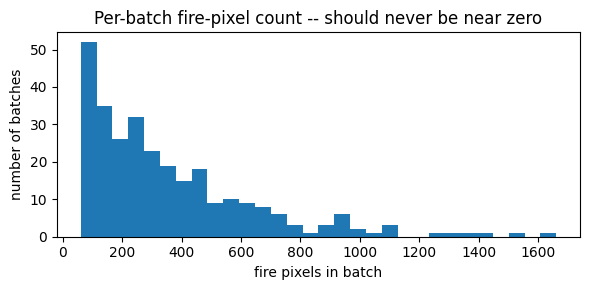

OK: every batch this epoch contains at least some fire signal.


In [ ]:
fire_per_batch = np.array([int(train_seq[i][1].sum()) for i in range(len(train_seq))])

print(f"batches checked: {len(fire_per_batch)}")
print(f"fire pixels per batch -- min: {fire_per_batch.min()}  median: {np.median(fire_per_batch):.0f}  "
      f"mean: {fire_per_batch.mean():.1f}  max: {fire_per_batch.max()}")
print(f"batches with zero fire pixels: {(fire_per_batch == 0).sum()} / {len(fire_per_batch)}")

plt.figure(figsize=(6, 3))
plt.hist(fire_per_batch, bins=30)
plt.xlabel("fire pixels in batch"); plt.ylabel("number of batches")
plt.title("Per-batch fire-pixel count -- should never be near zero")
plt.tight_layout(); plt.show()

assert fire_per_batch.min() > 0, (
    "Some batches have zero fire pixels -- check that fire_train_indices is non-empty and that "
    "FOREGROUND_FRACTION / n_fg are computed as intended before training."
)
print("OK: every batch this epoch contains at least some fire signal.")

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate,
                                     BatchNormalization, Activation, Dropout)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger, ReduceLROnPlateau


def conv_block(x, filters):
    for _ in range(2):
        x = Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
        x = BatchNormalization(momentum=BN_MOMENTUM)(x)
        x = Activation("relu")(x)
    return x


def build_unet(input_shape, base=BASE_FILTERS, dropout=DROPOUT, output_bias=0.0):
    inputs = Input(input_shape)
    skips, x = [], inputs
    for i in range(4):
        x = conv_block(x, base * 2 ** i)
        skips.append(x)
        x = MaxPooling2D(2)(x)
        x = Dropout(dropout)(x)
    x = conv_block(x, base * 16)
    for i in reversed(range(4)):
        x = Conv2DTranspose(base * 2 ** i, 3, strides=2, padding="same")(x)
        x = Dropout(dropout)(x)
        x = concatenate([x, skips[i]], axis=-1)
        x = conv_block(x, base * 2 ** i)
    outputs = Conv2D(1, 1, activation="sigmoid",
                     bias_initializer=tf.keras.initializers.Constant(output_bias))(x)
    return Model(inputs, outputs, name=f"unet_{base}f_2conv_{len(BAND_INDICES)}c")


model = build_unet((None, None, len(BAND_INDICES)), output_bias=output_bias)
n_trainable = sum(int(np.prod(w.shape)) for w in model.trainable_weights)
print(f"Trainable parameters: {n_trainable:,} | paper Table 1: {TARGET_PARAMS:,}")
if BASE_FILTERS == 16 and len(BAND_INDICES) == 3:
    assert n_trainable == TARGET_PARAMS, "Architecture does not match the paper's U-Net-Light (3c)."
    print("Architecture matches the paper exactly.")

# sanity check: the model's raw, untrained prediction should sit near p_fire, not near 0.5
sample_pred = float(model(train_seq[0][0][:1], training=False).numpy().mean())
print(f"mean predicted probability BEFORE any training: {sample_pred:.6f} (target ~ {p_fire:.6f})")
model.summary(line_length=100)

Trainable parameters: 2,161,649 | paper Table 1: 2,161,649
Architecture matches the paper exactly.
mean predicted probability BEFORE any training: 0.001150 (target ~ 0.001189)


Model: "unet_16f_2conv_3c"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)    │ (None, None, None, 3)   │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d (Conv2D)             │ (None, None, None, 16)  │            448 │ input_layer[0][0]       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization         │ (None, None, None, 16)  │             64 │ conv2d[0][0]            │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ activation (Activation)     │ (None, None, None, 16)  │              0 │ batch_normalization[0]… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_1 (Conv2D)           │ (None, None, None, 16)  │          2,320 │ activation[0][0]        │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization_1       │ (None, None, None, 16)  │             64 │ conv2d_1[0][0]          │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ activation_1 (Activation)   │ (None, None, None, 16)  │              0 │ batch_normalization_1[… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ max_pooling2d               │ (None, None, None, 16)  │              0 │ activation_1[0][0]      │
│ (MaxPooling2D)              │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ dropout (Dropout)           │ (None, None, None, 16)  │              0 │ max_pooling2d[0][0]     │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_2 (Conv2D)           │ (None, None, None, 32)  │          4,640 │ dropout[0][0]           │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization_2       │ (None, None, None, 32)  │            128 │ conv2d_2[0][0]          │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ activation_2 (Activation)   │ (None, None, None, 32)  │              0 │ batch_normalization_2[… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_3 (Conv2D)           │ (None, None, None, 32)  │          9,248 │ activation_2[0][0]      │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization_3       │ (None, None, None, 32)  │            128 │ conv2d_3[0][0]          │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ activation_3 (Activation)   │ (None, None, None, 32)  │              0 │ batch_normalization_3[… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ max_pooling2d_1             │ (None, None, None, 32)  │              0 │ activation_3[0][0]      │
│ (MaxPooling2D)              │                         │    

 Total params: 2,164,593 (8.26 MB)

 Trainable params: 2,161,649 (8.25 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [ ]:
class GlobalDice(tf.keras.metrics.Metric):
    """F-score / Dice = 2TP / (2TP + FP + FN), accumulated over all batches of an epoch."""
    def __init__(self, threshold=0.5, name="dice", **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        self.tp = self.add_weight(name="tp", shape=(), initializer="zeros")
        self.fp = self.add_weight(name="fp", shape=(), initializer="zeros")
        self.fn = self.add_weight(name="fn", shape=(), initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true > 0.5, tf.float32)
        y_pred = tf.cast(y_pred > self.threshold, tf.float32)
        self.tp.assign_add(tf.reduce_sum(y_true * y_pred))
        self.fp.assign_add(tf.reduce_sum((1.0 - y_true) * y_pred))
        self.fn.assign_add(tf.reduce_sum(y_true * (1.0 - y_pred)))

    def result(self):
        return 2.0 * self.tp / (2.0 * self.tp + self.fp + self.fn + 1e-7)

    def reset_state(self):
        self.tp.assign(0.0); self.fp.assign(0.0); self.fn.assign(0.0)


def focal_tversky_loss(y_true, y_pred):
    """Recall-focused loss for the highly sparse fire class (beta > alpha penalizes misses harder)."""
    smooth = tf.constant(1e-6, dtype=tf.float32)
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.clip_by_value(tf.cast(y_pred, tf.float32), smooth, 1.0 - smooth)
    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1.0 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1.0 - y_pred))
    tversky = (tp + smooth) / (tp + TVERSKY_ALPHA * fp + TVERSKY_BETA * fn + smooth)
    return tf.pow(1.0 - tversky, TVERSKY_GAMMA)


model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss=focal_tversky_loss,
    metrics=[GlobalDice(threshold=THRESHOLD, name="dice"),
             tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=THRESHOLD, name="iou"),
             tf.keras.metrics.Precision(thresholds=THRESHOLD, name="precision"),
             tf.keras.metrics.Recall(thresholds=THRESHOLD, name="recall")],
)

BEST_WEIGHTS = RUN_DIR / "best_unetlight3c_Schroeder.weights.h5"
FINAL_WEIGHTS = RUN_DIR / "final_unetlight3c_Schroeder.weights.h5"
callbacks = [
    ModelCheckpoint(str(BEST_WEIGHTS), monitor="val_dice", mode="max",
                    save_best_only=True, save_weights_only=True, verbose=1),
    EarlyStopping(monitor="val_dice", mode="max", patience=PATIENCE, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_dice", mode="max", factor=0.5,
                      patience=max(2, PATIENCE // 2), min_lr=1e-6, verbose=1),
    CSVLogger(str(RUN_DIR / "training_log.csv")),
]
print(f"Compiled: Adam(lr={LEARNING_RATE}), focal Tversky loss, batch {BATCH_SIZE}, max {EPOCHS} epochs, "
      f"early stopping + checkpoint + LR schedule all on val_dice (patience {PATIENCE}), metrics at threshold {THRESHOLD}")

Compiled: Adam(lr=0.001), focal Tversky loss, batch 16, max 50 epochs, early stopping + checkpoint + LR schedule all on val_dice (patience 8), metrics at threshold 0.25


In [ ]:
history = model.fit(train_seq, validation_data=val_seq, epochs=EPOCHS, callbacks=callbacks, verbose=2)
print("Train finished!")

Epoch 1/50

Epoch 1: val_dice improved from None to 0.26568, saving model to /content/output_unetlight3c/best_unetlight3c_Schroeder.weights.h5

Epoch 1: finished saving model to /content/output_unetlight3c/best_unetlight3c_Schroeder.weights.h5
287/287 - 57s - 200ms/step - dice: 0.2555 - iou: 0.1465 - loss: 0.7795 - precision: 0.2766 - recall: 0.2375 - val_dice: 0.2657 - val_iou: 0.1532 - val_loss: 0.8652 - val_precision: 0.2791 - val_recall: 0.2535 - learning_rate: 0.0010
Epoch 2/50

Epoch 2: val_dice improved from 0.26568 to 0.30129, saving model to /content/output_unetlight3c/best_unetlight3c_Schroeder.weights.h5

Epoch 2: finished saving model to /content/output_unetlight3c/best_unetlight3c_Schroeder.weights.h5
287/287 - 15s - 51ms/step - dice: 0.3248 - iou: 0.1939 - loss: 0.7144 - precision: 0.6550 - recall: 0.2160 - val_dice: 0.3013 - val_iou: 0.1774 - val_loss: 0.6989 - val_precision: 0.3744 - val_recall: 0.2521 - learning_rate: 0.0010
Epoch 3/50

Epoch 3: val_dice did not improv

,dice,iou,loss,precision,recall,val_dice,val_iou,val_loss,val_precision,val_recall,learning_rate
epoch,,,,,,,,,,,
1,0.2555,0.1465,0.7795,0.2766,0.2375,0.2657,0.1532,0.8652,0.2791,0.2535,0.0010
2,0.3248,0.1939,0.7144,0.6550,0.2160,0.3013,0.1774,0.6989,0.3744,0.2521,0.0010
3,0.3444,0.2080,0.7103,0.5883,0.2434,0.2989,0.1757,0.6617,0.3582,0.2564,0.0010
4,0.2998,0.1763,0.7333,0.6826,0.1921,0.3210,0.1912,0.6009,0.4395,0.2528,0.0010
5,0.3170,0.1884,0.7213,0.4063,0.2599,0.2863,0.1671,0.6537,0.3236,0.2568,0.0010
6,0.3332,0.1999,0.7075,0.4967,0.2507,0.2712,0.1569,0.6684,0.2813,0.2618,0.0010
7,0.2885,0.1686,0.7062,0.6520,0.1852,0.3058,0.1805,0.5792,0.3711,0.2600,0.0010
8,0.3459,0.2091,0.6865,0.7236,0.2272,0.3225,0.1922,0.5393,0.4440,0.2532,0.0010
9,0.3742,0.2302,0.6628,0.7383,0.2506,0.3280,0.1962,0.5158,0.4757,0.2503,0.0010



Best epoch by val_dice: 35
loss             0.4956
val_loss         0.4993
dice             0.5434
val_dice         0.6629
iou              0.3731
val_iou          0.4957
precision        0.4531
val_precision    0.6194
recall           0.6786
val_recall       0.7129


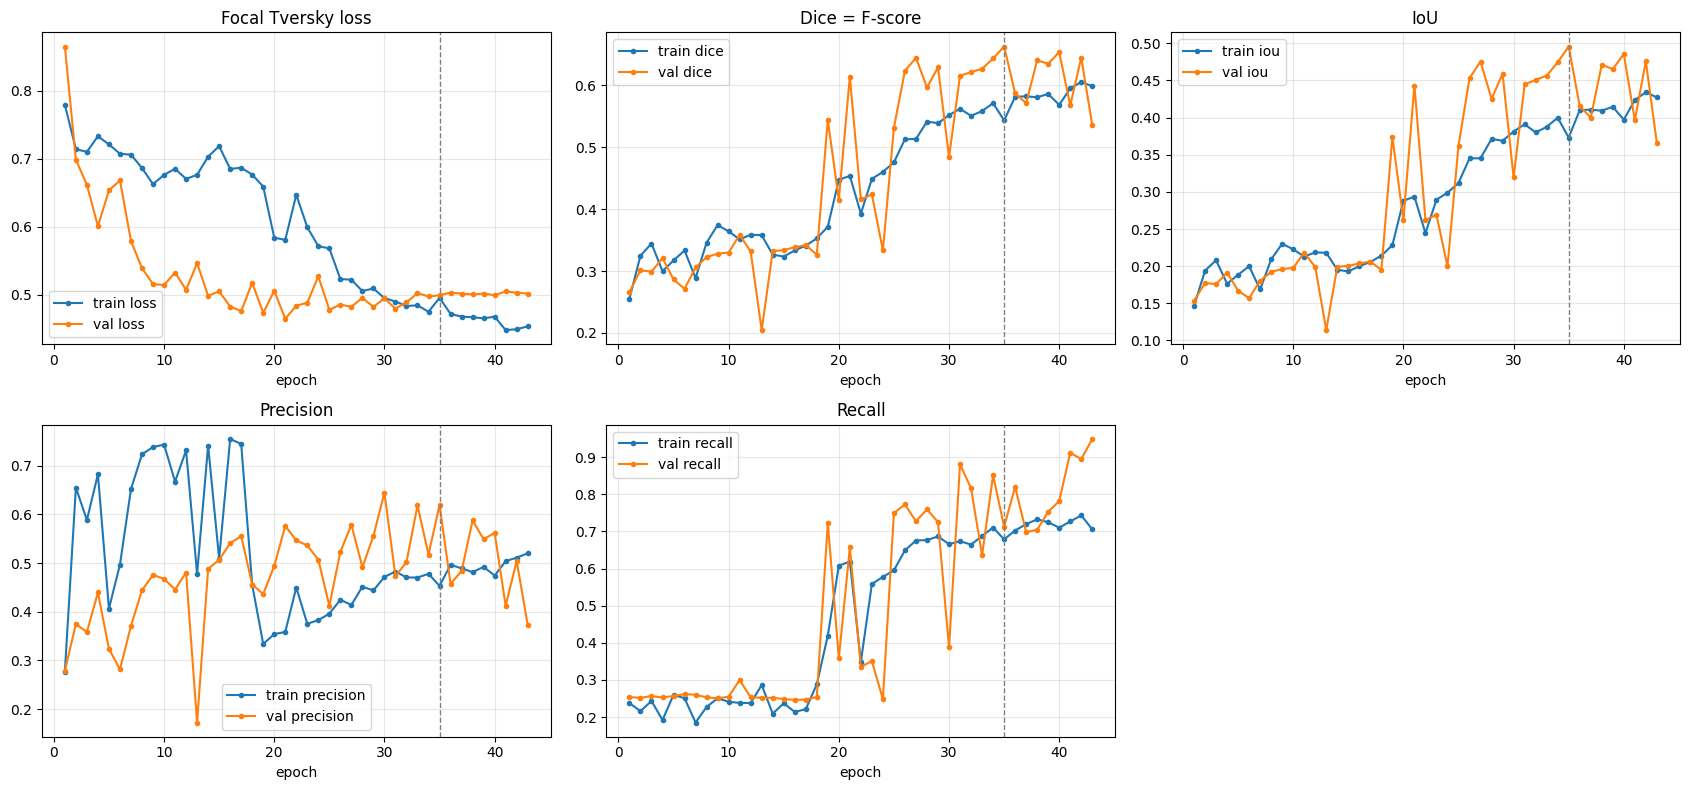

In [ ]:
hist = pd.DataFrame(history.history)
hist.index = np.arange(1, len(hist) + 1)
hist.index.name = "epoch"
hist.to_csv(RUN_DIR / "history_unetlight3c_Schroeder.csv")

best_epoch = int(hist["val_dice"].idxmax())
model.load_weights(str(BEST_WEIGHTS))
model.save_weights(str(FINAL_WEIGHTS))

display(hist.round(4))
print(f"\nBest epoch by val_dice: {best_epoch}")
print(hist.loc[best_epoch, ["loss", "val_loss", "dice", "val_dice", "iou", "val_iou",
                            "precision", "val_precision", "recall", "val_recall"]].round(4).to_string())

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, (key, title) in zip(axes.ravel(), [("loss", "Focal Tversky loss"), ("dice", "Dice = F-score"), ("iou", "IoU"),
                                            ("precision", "Precision"), ("recall", "Recall")]):
    ax.plot(hist.index, hist[key], marker="o", ms=3, label=f"train {key}")
    ax.plot(hist.index, hist[f"val_{key}"], marker="o", ms=3, label=f"val {key}")
    ax.axvline(best_epoch, color="gray", ls="--", lw=1)
    ax.set_title(title); ax.set_xlabel("epoch"); ax.grid(True, alpha=0.3); ax.legend()
axes.ravel()[5].axis("off")
plt.tight_layout(); plt.show()

In [ ]:
def confusion_counts(model, seq, thresholds):
    thresholds = list(thresholds)
    counts = {t: np.zeros(3, dtype=np.int64) for t in thresholds}
    for i in range(len(seq)):
        x, y = seq[i]
        p = np.asarray(model(x, training=False))
        yt = y > 0.5
        for t in thresholds:
            yp = p > t
            counts[t] += [np.sum(yt & yp), np.sum(~yt & yp), np.sum(yt & ~yp)]
    return counts


def paper_metrics(tp, fp, fn):
    # 0.0 (not NaN) when the denominator is 0, matching tf.keras.metrics.Precision/Recall's convention --
    # keeps this comparable to model.evaluate() even in edge cases (e.g. a model predicting no positives at all).
    P = tp / (tp + fp) if (tp + fp) else 0.0
    R = tp / (tp + fn) if (tp + fn) else 0.0
    F = 2 / (1 / P + 1 / R) if (P > 0 and R > 0) else 0.0
    IoU = tp / (tp + fp + fn) if (tp + fp + fn) else 0.0
    return {"P": 100 * P, "R": 100 * R, "IoU": 100 * IoU, "F": 100 * F}


tp, fp, fn = confusion_counts(model, test_seq, [THRESHOLD])[THRESHOLD]
ours = paper_metrics(tp, fp, fn)
comparison = pd.DataFrame({"paper (Table 2)": PAPER_TARGET, "this notebook": ours}).T[["P", "R", "IoU", "F"]]
comparison.loc["difference"] = comparison.loc["this notebook"] - comparison.loc["paper (Table 2)"]
n_test_negative = int((~cache["has_mask"][split["test"]]).sum())
print(f"Test set: {len(split['test'])} patches ({n_test_negative} Schroeder-negative) | threshold {THRESHOLD} | tp={tp:,} fp={fp:,} fn={fn:,}")
display(comparison.round(1))

Test set: 1313 patches (827 Schroeder-negative) | threshold 0.25 | tp=3,213 fp=3,295 fn=1,526


,P,R,IoU,F
paper (Table 2),90.8,86.1,79.2,88.4
this notebook,49.4,67.8,40.0,57.1
difference,-41.4,-18.3,-39.2,-31.3


In [ ]:
res = model.evaluate(test_seq, return_dict=True, verbose=0)
print(f"Keras  : F(dice)={100 * res['dice']:.2f}  P={100 * res['precision']:.2f}  R={100 * res['recall']:.2f}  IoU={100 * res['iou']:.2f}  test loss={res['loss']:.5f}")
print(f"Counts : F        ={ours['F']:.2f}  P={ours['P']:.2f}  R={ours['R']:.2f}  IoU={ours['IoU']:.2f}")
ok = abs(100 * res["dice"] - ours["F"]) < 0.05 and abs(100 * res["precision"] - ours["P"]) < 0.05 and abs(100 * res["recall"] - ours["R"]) < 0.05
print("Consistent." if ok else "MISMATCH: inspect the metric definitions.")

res_train = model.evaluate(TileSequence(cache, split["train"]), return_dict=True, verbose=0)
res_val = model.evaluate(val_seq, return_dict=True, verbose=0)
display(pd.DataFrame({"train": res_train, "val": res_val, "test": res}).T.round(4))

Keras  : F(dice)=57.14  P=49.37  R=67.80  IoU=39.99  test loss=0.47818
Counts : F        =57.14  P=49.37  R=67.80  IoU=39.99
Consistent.


,dice,iou,loss,precision,recall
train,0.6388,0.4693,0.4628,0.6048,0.6769
val,0.6629,0.4957,0.4993,0.6194,0.7129
test,0.5714,0.3999,0.4782,0.4937,0.6780


In [ ]:
rows = {}
for name, r in [("North Africa", 0), ("South Europe", 1)]:
    idx = split["test"][cache["region"][split["test"]] == r]
    if len(idx) == 0:
        continue
    tp_r, fp_r, fn_r = confusion_counts(model, TileSequence(cache, idx), [THRESHOLD])[THRESHOLD]
    rows[f"{name} ({len(idx)} patches)"] = paper_metrics(tp_r, fp_r, fn_r)
display(pd.DataFrame(rows).T[["P", "R", "IoU", "F"]].round(1))

sweep_thr = np.round(np.arange(0.05, 0.96, 0.10), 2).tolist() + [THRESHOLD]
val_counts = confusion_counts(model, val_seq, sweep_thr)
sweep = pd.DataFrame({t: paper_metrics(*val_counts[t]) for t in sorted(set(sweep_thr))}).T[["P", "R", "IoU", "F"]]
sweep.index.name = "threshold"
print("Validation set, metrics (%) vs threshold:")
display(sweep.round(1))

,P,R,IoU,F
North Africa (247 patches),48.7,59.7,36.6,53.6
South Europe (1066 patches),50.8,92.1,48.6,65.4


Validation set, metrics (%) vs threshold:


,P,R,IoU,F
threshold,,,,
0.05,55.9,80.2,49.1,65.9
0.15,60.0,74.5,49.8,66.5
0.25,61.9,71.3,49.6,66.3
0.35,63.0,68.6,48.9,65.7
0.45,63.7,65.7,47.8,64.7
0.55,63.9,63.1,46.5,63.5
0.65,64.6,61.1,45.8,62.8
0.75,65.2,58.0,44.3,61.4
0.85,65.6,54.4,42.3,59.5


### Visualize the patch with the most fire pixels and its mask

Displaying the top 10 patches with the most fire pixels (based on Schroeder GT)...


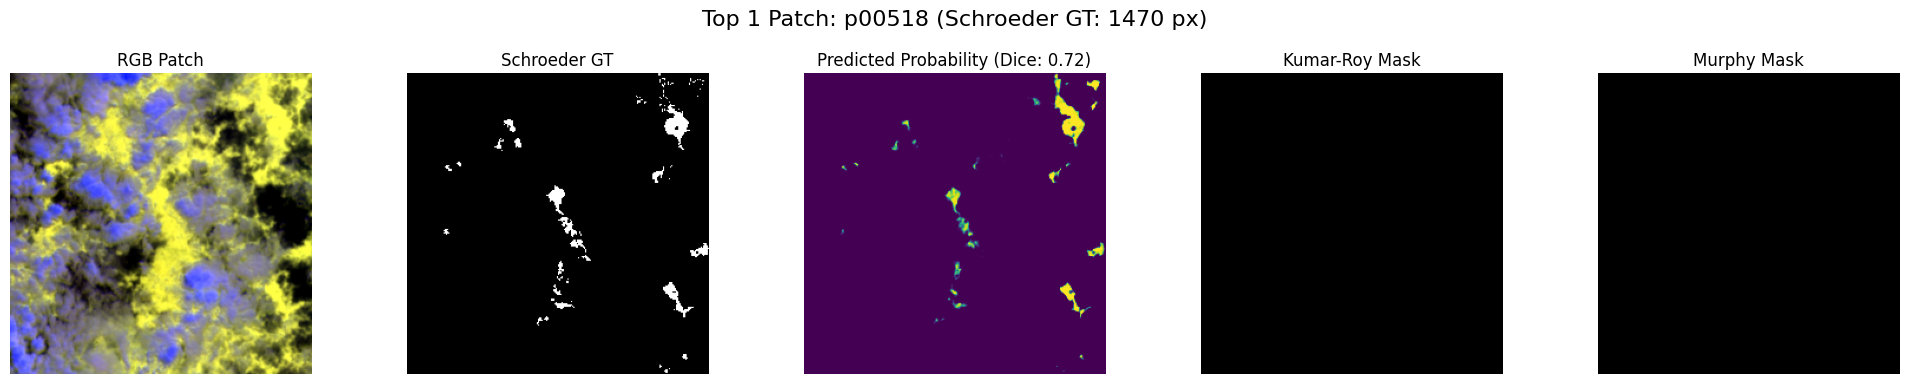

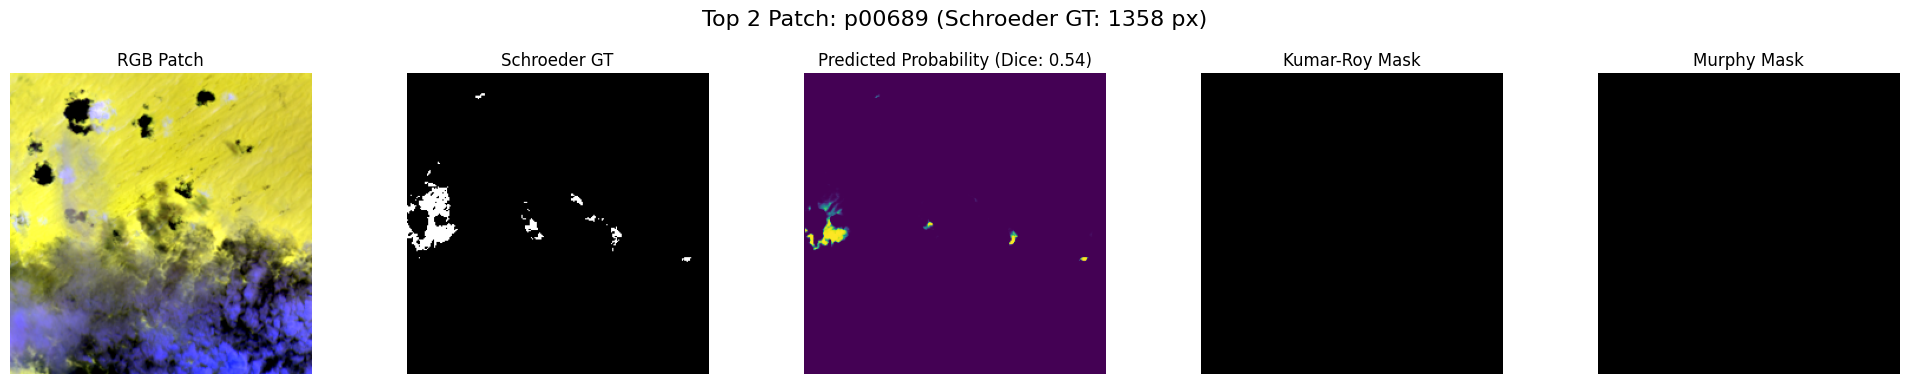

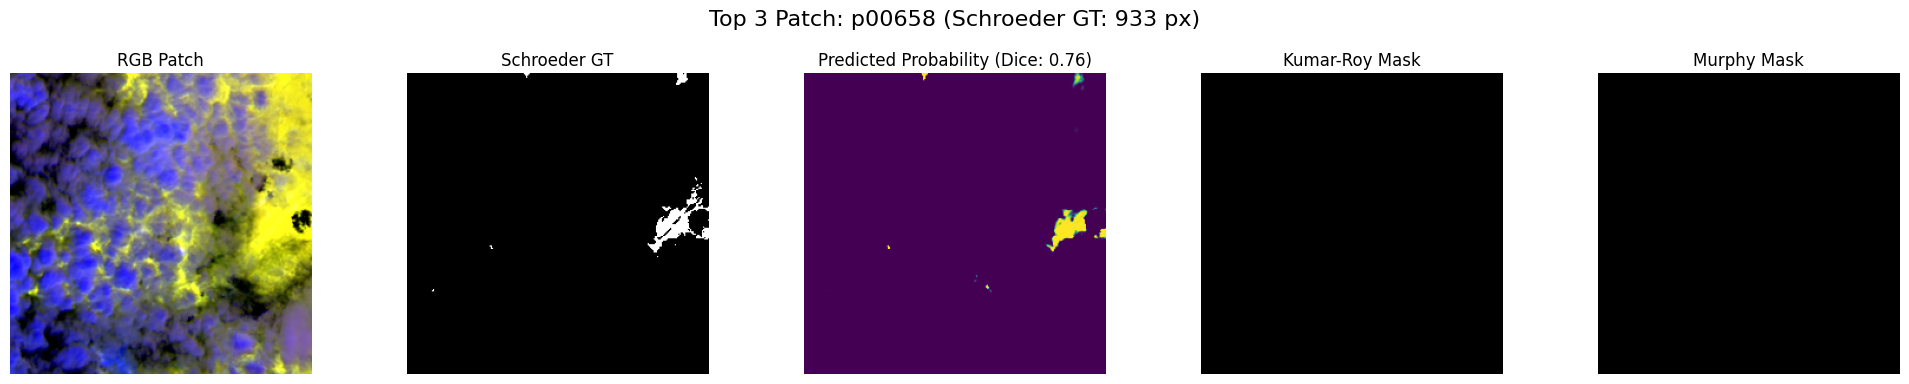

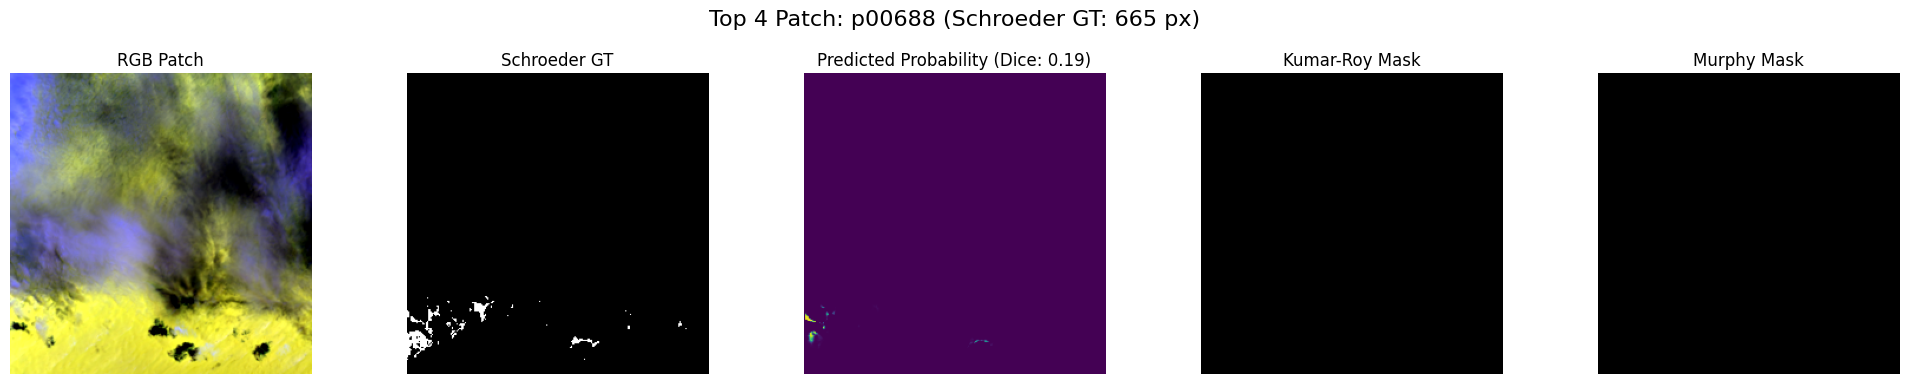

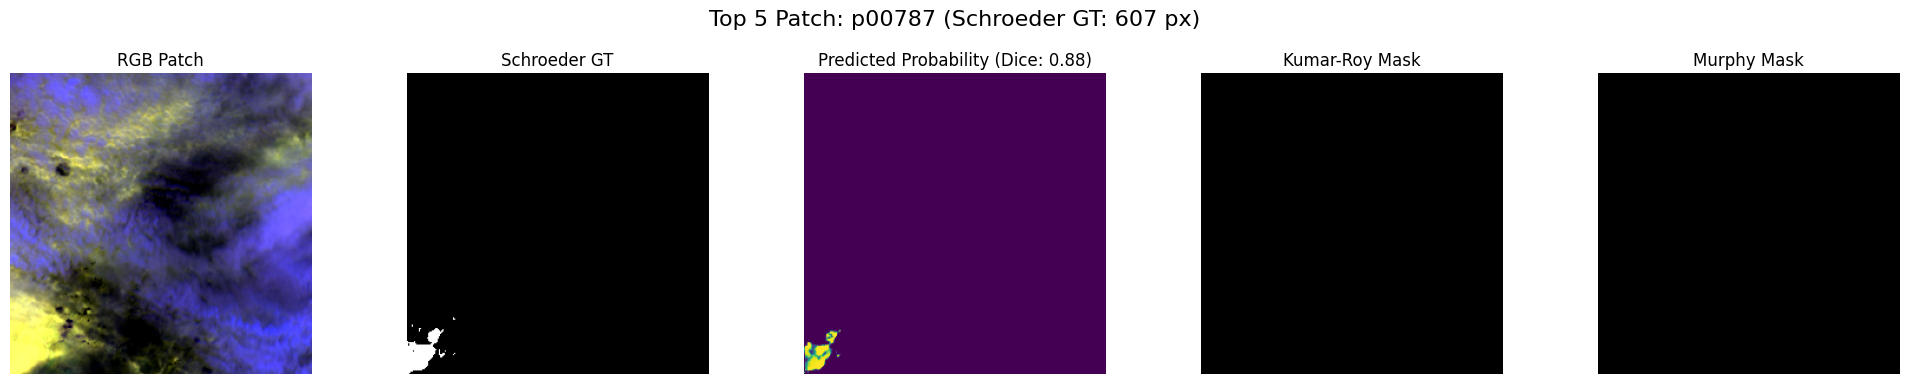

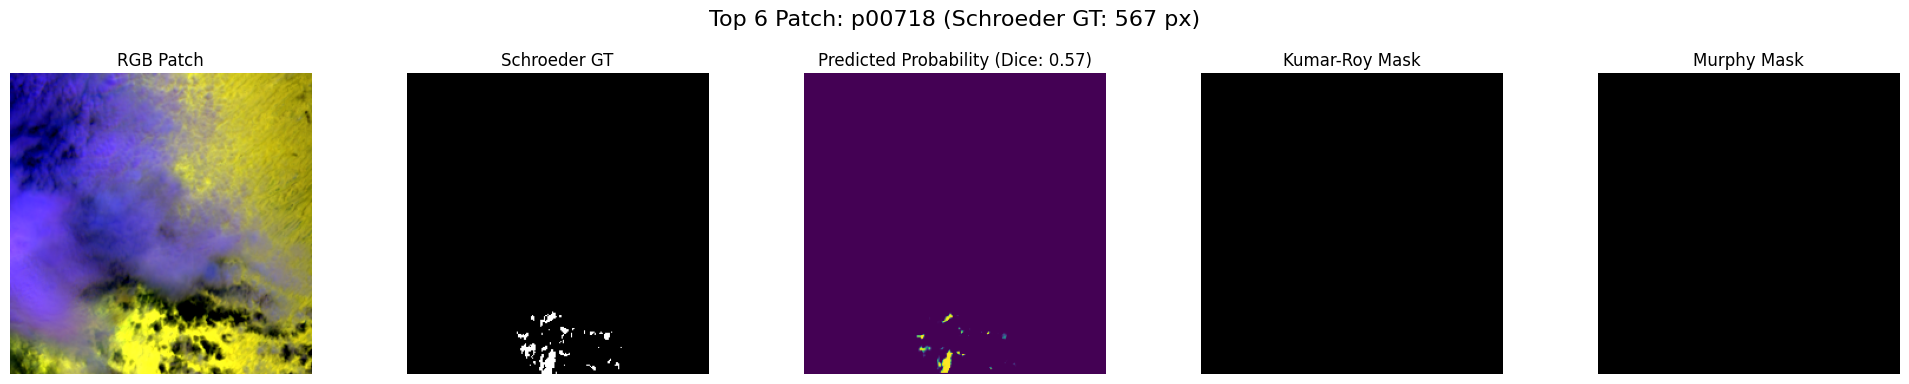

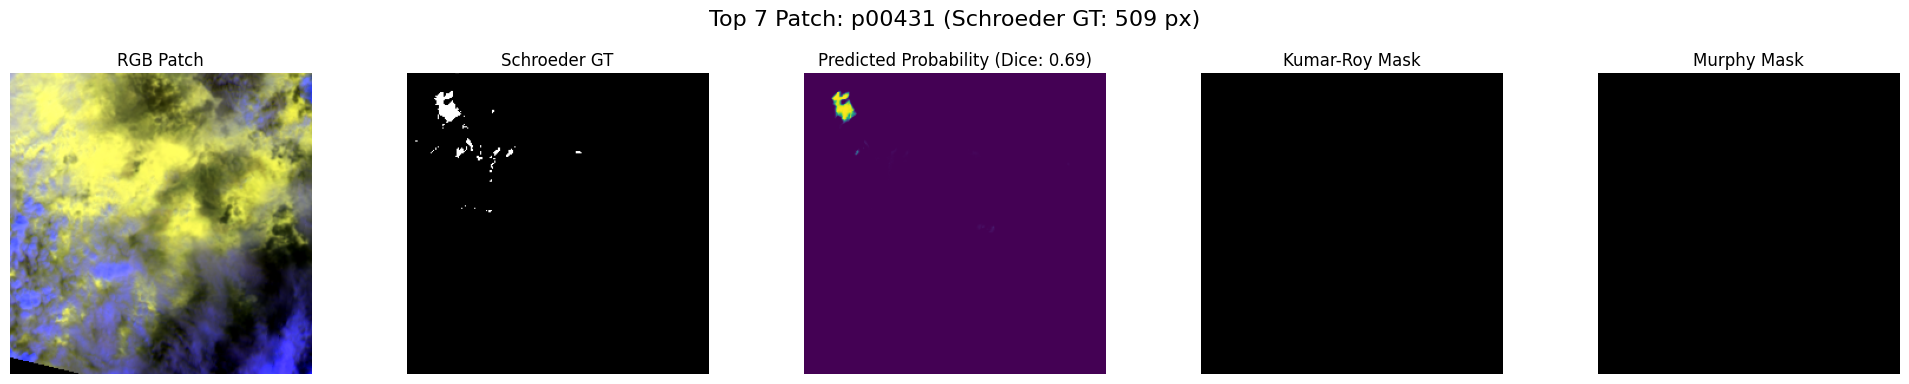

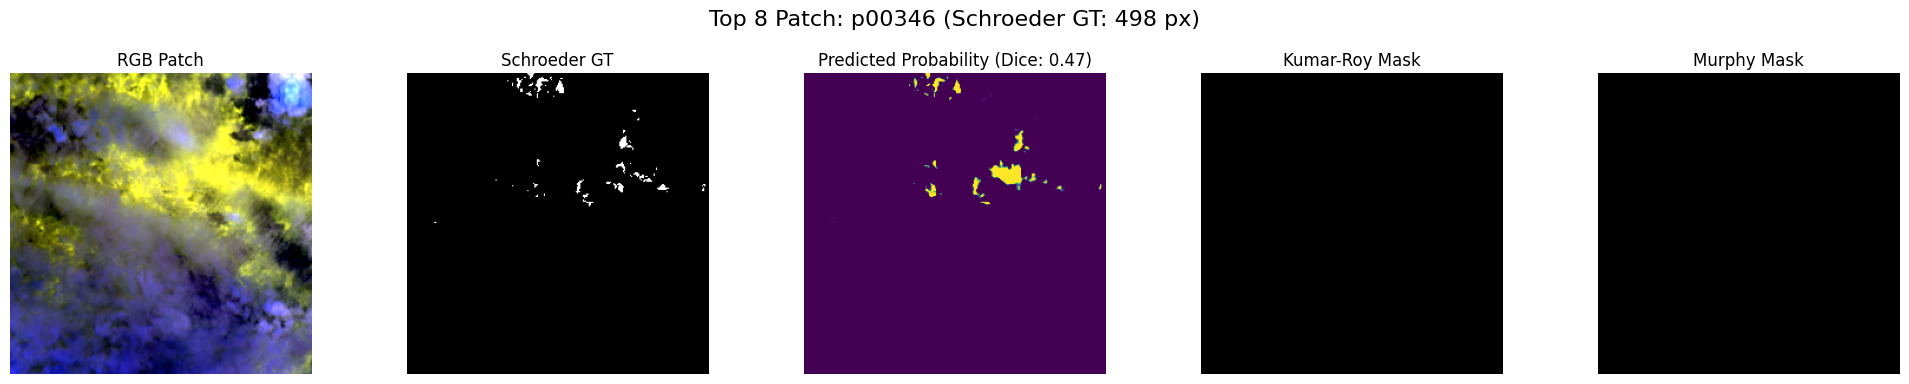

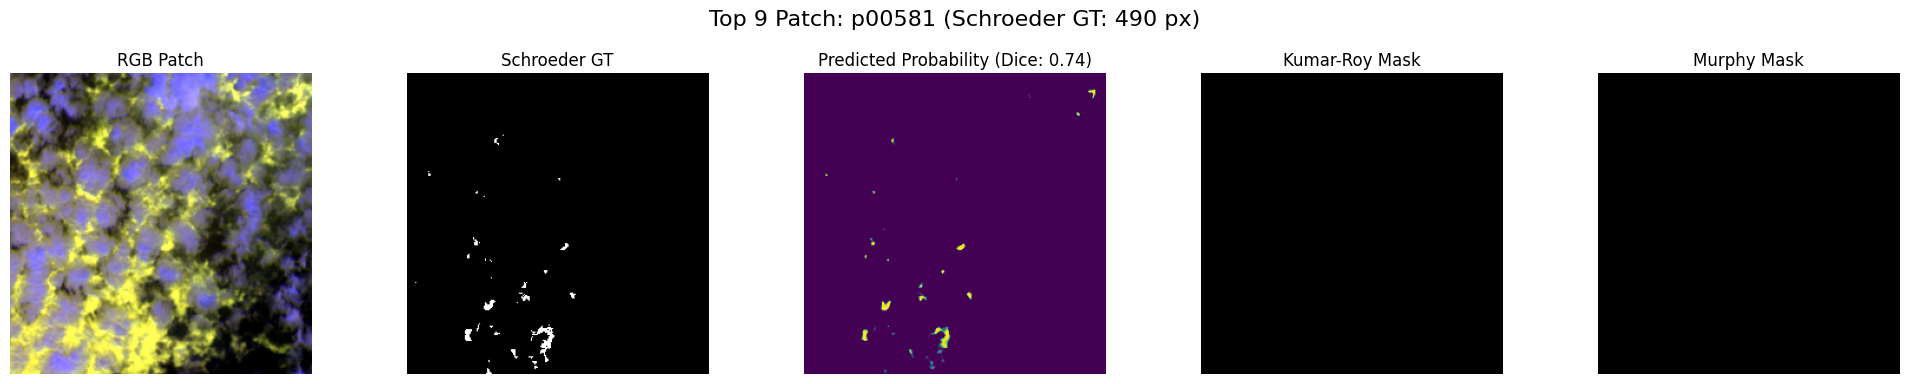

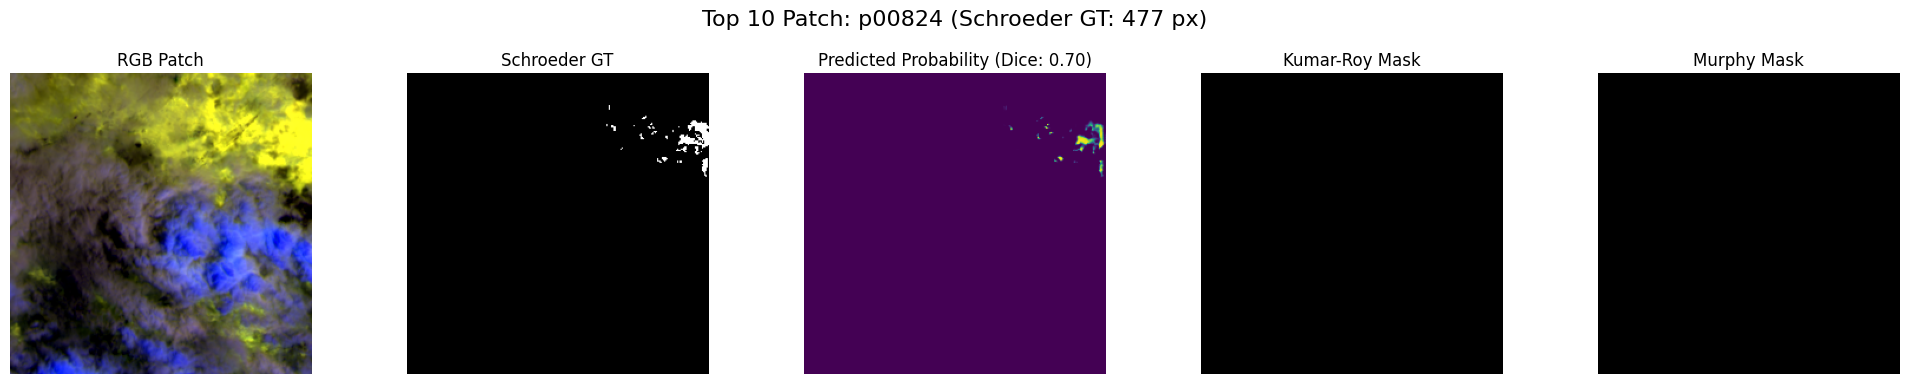

In [ ]:
fire_counts_all_patches = cache["masks"].reshape(len(cache["masks"]), -1).sum(axis=1)

# Find the indices of the top 10 patches with the most fire pixels
# Use argsort to get indices that would sort the array, then take the last 10 (largest values)
# [::-1] reverses the array to get descending order
top_10_fire_patch_indices = np.argsort(fire_counts_all_patches)[::-1][:10]

print(f"Displaying the top 10 patches with the most fire pixels (based on Schroeder GT)...")

for i, patch_idx in enumerate(top_10_fire_patch_indices):
    # Get the image and Schroeder ground truth mask from the cache for this patch
    x_patch_current = cache["images"][patch_idx].astype(np.float32) / SCALE
    gt_schroeder_mask_current = cache["masks"][patch_idx]

    # Generate RGB image for display
    rgb_display_current = np.stack([np.clip((x_patch_current[..., k] - np.percentile(x_patch_current[..., k], 2)) /
                                (np.percentile(x_patch_current[..., k], 98) - np.percentile(x_patch_current[..., k], 2) + 1e-9), 0, 1) for k in range(3)], axis=-1)

    # Get scene and stem information to locate other masks
    scene_name_current = cache["scenes"][patch_idx]
    stem_name_current = cache["stems"][patch_idx]

    # Determine main zip path and img_zip_name
    main_zip_path_current = "Africa.zip" if "North Africa" in scene_name_current else "Europe.zip"
    img_zip_name_current = scene_name_current.split('/')[-1]
    patch_id_current = stem_name_current.split('_')[-1]

    # Load Kumar-Roy and Murphy masks using the helper function
    kumar_mask_current, murphy_mask_current = load_other_masks_for_patch(main_zip_path_current, img_zip_name_current, patch_id_current)

    # Get the model's prediction for this patch
    predicted_prob_current = np.asarray(model(x_patch_current[None], training=False))[0, ..., 0]

    # Calculate binary prediction mask
    predicted_binary_mask_current = predicted_prob_current > THRESHOLD

    # Calculate Dice score for the current patch
    y_true_flat = gt_schroeder_mask_current.flatten()
    y_pred_flat = predicted_binary_mask_current.flatten()

    tp = np.sum((y_true_flat == 1) & (y_pred_flat == 1))
    fp = np.sum((y_true_flat == 0) & (y_pred_flat == 1))
    fn = np.sum((y_true_flat == 1) & (y_pred_flat == 0))

    # Add a small epsilon to avoid division by zero
    dice_score = (2 * tp) / (2 * tp + fp + fn + 1e-7)

    # Plotting
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(f"Top {i+1} Patch: {patch_id_current} (Schroeder GT: {int(gt_schroeder_mask_current.sum())} px)", fontsize=16)

    axes[0].imshow(rgb_display_current)
    axes[0].set_title(f"RGB Patch")

    axes[1].imshow(gt_schroeder_mask_current, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title(f"Schroeder GT")

    axes[2].imshow(predicted_prob_current, cmap="viridis", vmin=0, vmax=1)
    axes[2].set_title(f"Predicted Probability (Dice: {dice_score:.2f})")

    axes[3].imshow(kumar_mask_current, cmap="gray", vmin=0, vmax=1)
    axes[3].set_title("Kumar-Roy Mask")

    axes[4].imshow(murphy_mask_current, cmap="gray", vmin=0, vmax=1)
    axes[4].set_title("Murphy Mask")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
    plt.show()